# Side-by-side PLY / MRI breathing motion viewer

Shows a PLY point cloud and an MRI slice side by side, each on its **own independent frame index** -- so you can compare, e.g., PLY frame 1 against MRI frame 12, not just matched timepoints. Also plots the frame-to-frame motion amplitude of each modality for direct comparison, with a cursor for each modality's current position.

**Before running this**: `MRI_DIR` below must point to a folder containing ONLY the volume-slice DICOM files, not navigator+volume mixed together. Use `explore_mri_series.py` + `split_dicom_by_attribute.py` (e.g. filtering on `TriggerTime`) to produce that folder first if you haven't already.

**Units**: PLY point clouds are commonly in metres; `PLY_UNIT_SCALE` converts to mm so both amplitude curves are on the same physical scale. Check the printed bounding-box size after loading -- if your `.ply` files were already normalized to an arbitrary unit sphere, undo that first.

**MRI amplitude is in-plane only**: your MRI is a single 2D slice per timepoint, not a 3D volume, so the MRI amplitude is a 2D displacement-field magnitude (via deformable registration), not a true 3D distance -- comparable in *kind* (both mm displacement magnitudes) to the PLY amplitude, but it won't capture through-plane liver motion.

## Config -- edit these paths for your data

In [6]:
PLY_DIR = Path("/volatile/Datasets/Varian_Motion/chum/9_11/pc/small_antenna_av_filt")
MRI_DIR = Path("/volatile/Datasets/Varian_Motion/chum/9_11/mri/small_Series0801_vol")  # filtered, NOT the mixed navigator+volume folder

FRAME_INTERVAL_MS = 450.0     # nominal; real elapsed time is used instead when AcquisitionTime is available
PLY_UNIT_SCALE = 1000.0       # e.g. 1000.0 to convert metres -> mm; set to 1.0 if already mm
PLY_MAX_DISPLAY_POINTS = 3000 # subsample for responsive 3D rendering (display only, not amplitude calc)

OUTPUT_CSV_PLY = Path("./output/ply_frame_to_frame_amplitude.csv")
OUTPUT_CSV_MRI = Path("./output/mri_frame_to_frame_amplitude.csv")

## Loading + temporal sorting helpers

MRI frames are ordered by DICOM `AcquisitionTime` (falls back to filename order with a warning), not alphabetical filename -- UID-based filenames aren't guaranteed to match acquisition order.

In [2]:
def looks_like_dicom(path: Path) -> bool:
    if not path.is_file():
        return False
    if path.name.upper() == "DICOMDIR":
        return False
    try:
        with open(path, "rb") as f:
            preamble = f.read(132)
    except OSError:
        return False
    return len(preamble) == 132 and preamble[128:132] == b"DICM"


def parse_dicom_time(time_str):
    if not time_str:
        return None
    time_str = time_str.strip()
    if len(time_str) < 6:
        return None
    try:
        return int(time_str[0:2]) * 3600 + int(time_str[2:4]) * 60 + float(time_str[4:])
    except ValueError:
        return None


def get_acquisition_time(path: Path):
    try:
        ds = pydicom.dcmread(str(path), stop_before_pixels=True, force=True)
    except Exception:
        return None
    return parse_dicom_time(str(getattr(ds, "AcquisitionTime", "")))


def load_sorted_mri_files(mri_dir: Path):
    files = sorted(p for p in mri_dir.iterdir() if looks_like_dicom(p))
    if not files:
        raise ValueError(f"No DICOM files found in {mri_dir}")
    times = [get_acquisition_time(p) for p in files]
    if all(t is not None for t in times):
        order = sorted(range(len(files)), key=lambda i: times[i])
        files = [files[i] for i in order]
        times = [times[i] for i in order]
        t0 = times[0]
        time_ms = [(t - t0) * 1000.0 for t in times]
    else:
        print("  [warn] AcquisitionTime missing for some MRI frames -- "
              "falling back to filename order and a nominal frame interval.")
        time_ms = [i * FRAME_INTERVAL_MS for i in range(len(files))]
    return files, time_ms


def load_ply_points(path: Path, unit_scale: float) -> np.ndarray:
    pcd = o3d.io.read_point_cloud(str(path))
    pts = np.asarray(pcd.points, dtype=np.float64) * unit_scale
    if len(pts) == 0:
        raise ValueError(f"Empty point cloud: {path}")
    return pts

## Load both sequences (independently -- lengths don't need to match)

In [7]:
ply_files = sorted(PLY_DIR.glob("*.ply"))
mri_files, mri_time_ms = load_sorted_mri_files(MRI_DIR)

n_ply = len(ply_files)
n_mri = len(mri_files)
ply_time_ms = [i * FRAME_INTERVAL_MS for i in range(n_ply)]  # ply has no AcquisitionTime

print(f"PLY frames: {n_ply}")
print(f"MRI frames: {n_mri}")

# units sanity check
sample_pts = load_ply_points(ply_files[0], PLY_UNIT_SCALE)
bbox_size = sample_pts.max(0) - sample_pts.min(0)
print(f"[units check] first PLY frame bbox size (x,y,z): {bbox_size} "
      f"(after PLY_UNIT_SCALE={PLY_UNIT_SCALE}) -- should be a few hundred mm "
      f"for a real abdominal surface if working in mm.")

PLY frames: 596
MRI frames: 594
[units check] first PLY frame bbox size (x,y,z): [430.173859   158.48141909 449.71436262] (after PLY_UNIT_SCALE=1000.0) -- should be a few hundred mm for a real abdominal surface if working in mm.


## Precompute frame-to-frame amplitude for each modality independently

- **PLY**: bidirectional nearest-neighbour distance between consecutive point clouds (raw whole-surface displacement, no rigid pre-alignment removed).
- **MRI**: 2D deformable (Demons) registration between consecutive volume-slice images; displacement field magnitude in mm via pixel spacing.

Each sequence is processed on its own timeline (they don't need to be the same length), and results are cached to CSV.

In [8]:
def pointcloud_pair_amplitude(pts_a: np.ndarray, pts_b: np.ndarray) -> dict:
    """Bidirectional NN distance between two point sets -> mean/rms/max, mm."""
    tree_b = cKDTree(pts_b)
    d_a_to_b, _ = tree_b.query(pts_a, k=1, workers=-1)
    tree_a = cKDTree(pts_a)
    d_b_to_a, _ = tree_a.query(pts_b, k=1, workers=-1)
    d = np.concatenate([d_a_to_b, d_b_to_a])
    return {"mean": float(d.mean()), "rms": float(np.sqrt((d ** 2).mean())), "max": float(d.max())}


def mri_pair_amplitude(image_a: sitk.Image, image_b: sitk.Image) -> dict:
    """2D Demons registration between two MRI slices -> displacement magnitude
    mean/rms/max, mm. In-plane only, see limitation note at the top."""
    a = sitk.Cast(image_a, sitk.sitkFloat32)
    b = sitk.Cast(image_b, sitk.sitkFloat32)
    b_resampled = sitk.Resample(b, a)

    demons = sitk.DemonsRegistrationFilter()
    demons.SetNumberOfIterations(50)
    demons.SetStandardDeviations(1.5)
    field = demons.Execute(a, b_resampled)

    field_array = sitk.GetArrayFromImage(field)
    magnitude = np.linalg.norm(field_array, axis=-1).ravel()
    return {"mean": float(magnitude.mean()), "rms": float(np.sqrt((magnitude ** 2).mean())),
            "max": float(magnitude.max())}


def compute_amplitude_series(n_frames, load_frame_fn, pair_amplitude_fn, time_ms_list, label):
    rows = []
    prev = None
    for i in range(n_frames):
        current = load_frame_fn(i)
        if i == 0:
            rows.append({"frame_index": i, "time_ms": time_ms_list[i],
                         "mean_mm": "", "rms_mm": "", "max_mm": ""})
        else:
            amp = pair_amplitude_fn(prev, current)
            rows.append({"frame_index": i, "time_ms": time_ms_list[i],
                         "mean_mm": amp["mean"], "rms_mm": amp["rms"], "max_mm": amp["max"]})
        prev = current
        if i % 20 == 0:
            print(f"  [{label}] processed {i + 1}/{n_frames}")
    return rows


ply_rows = compute_amplitude_series(
    n_ply,
    lambda i: load_ply_points(ply_files[i], PLY_UNIT_SCALE),
    pointcloud_pair_amplitude,
    ply_time_ms, "PLY",
)
mri_rows = compute_amplitude_series(
    n_mri,
    lambda i: sitk.ReadImage(str(mri_files[i])),
    mri_pair_amplitude,
    mri_time_ms, "MRI",
)

for path, rows in [(OUTPUT_CSV_PLY, ply_rows), (OUTPUT_CSV_MRI, mri_rows)]:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved {path}")

  [PLY] processed 1/596
  [PLY] processed 21/596
  [PLY] processed 41/596
  [PLY] processed 61/596
  [PLY] processed 81/596
  [PLY] processed 101/596
  [PLY] processed 121/596
  [PLY] processed 141/596
  [PLY] processed 161/596
  [PLY] processed 181/596
  [PLY] processed 201/596
  [PLY] processed 221/596
  [PLY] processed 241/596
  [PLY] processed 261/596
  [PLY] processed 281/596
  [PLY] processed 301/596
  [PLY] processed 321/596
  [PLY] processed 341/596
  [PLY] processed 361/596
  [PLY] processed 381/596
  [PLY] processed 401/596
  [PLY] processed 421/596
  [PLY] processed 441/596
  [PLY] processed 461/596
  [PLY] processed 481/596
  [PLY] processed 501/596
  [PLY] processed 521/596
  [PLY] processed 541/596
  [PLY] processed 561/596
  [PLY] processed 581/596
  [MRI] processed 1/594
  [MRI] processed 21/594
  [MRI] processed 41/594
  [MRI] processed 61/594
  [MRI] processed 81/594
  [MRI] processed 101/594
  [MRI] processed 121/594
  [MRI] processed 141/594
  [MRI] processed 161/59

## Amplitude comparison plot

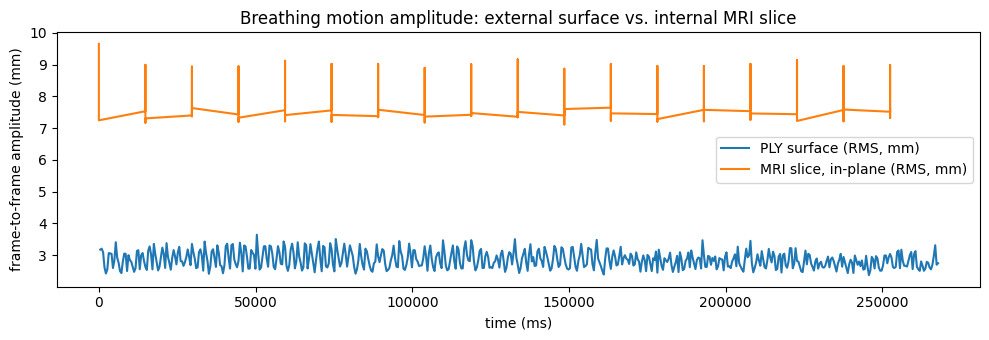

In [9]:
ply_times_plot = [r["time_ms"] for r in ply_rows[1:]]
ply_rms_plot = [r["rms_mm"] for r in ply_rows[1:]]
mri_times_plot = [r["time_ms"] for r in mri_rows[1:]]
mri_rms_plot = [r["rms_mm"] for r in mri_rows[1:]]

fig_amp, ax_amp = plt.subplots(figsize=(10, 3.5))
ax_amp.plot(ply_times_plot, ply_rms_plot, label="PLY surface (RMS, mm)", color="tab:blue")
ax_amp.plot(mri_times_plot, mri_rms_plot, label="MRI slice, in-plane (RMS, mm)", color="tab:orange")
ax_amp.set_xlabel("time (ms)")
ax_amp.set_ylabel("frame-to-frame amplitude (mm)")
ax_amp.set_title("Breathing motion amplitude: external surface vs. internal MRI slice")
ax_amp.legend()
plt.tight_layout()
plt.show()

## Interactive side-by-side viewer -- independent navigation per modality

Two separate sliders/Prev-Next pairs: one for the PLY frame, one for the MRI frame. Pick any combination, e.g. PLY frame 1 with MRI frame 12. Each panel's current frame index and time are shown above it; the amplitude plot below has one cursor per modality (blue = PLY, orange = MRI) so you can see where each selection sits in its own breathing-amplitude curve.

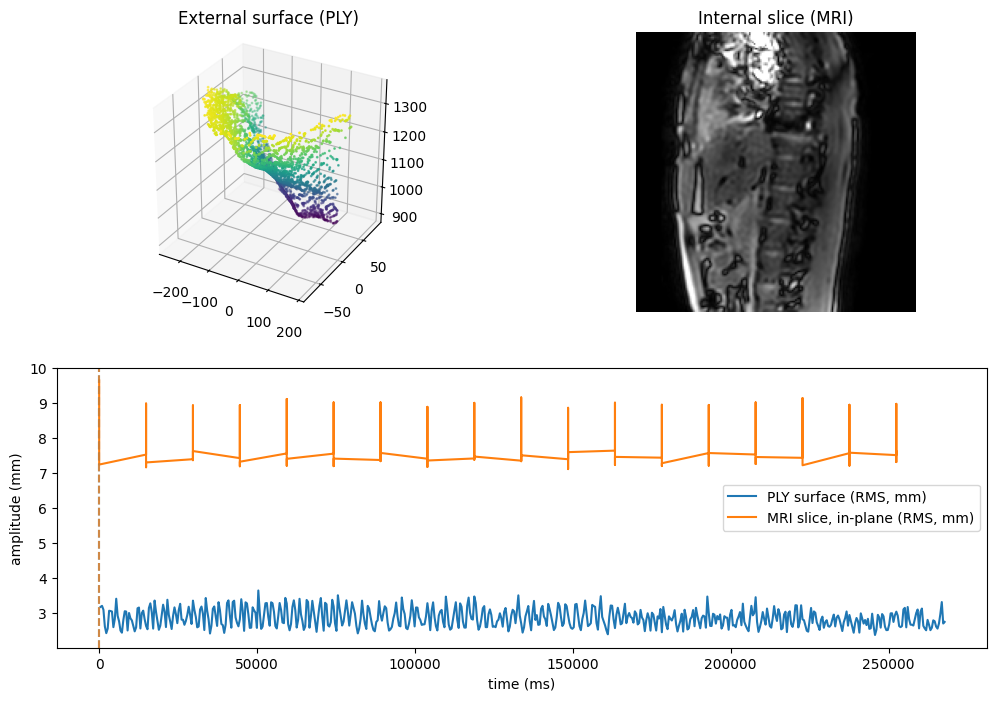

In [10]:
fig = plt.figure(figsize=(12, 8))
ax_ply = fig.add_subplot(2, 2, 1, projection="3d")
ax_mri = fig.add_subplot(2, 2, 2)
ax_curve = fig.add_subplot(2, 1, 2)

ax_curve.plot(ply_times_plot, ply_rms_plot, label="PLY surface (RMS, mm)", color="tab:blue")
ax_curve.plot(mri_times_plot, mri_rms_plot, label="MRI slice, in-plane (RMS, mm)", color="tab:orange")
ax_curve.set_xlabel("time (ms)")
ax_curve.set_ylabel("amplitude (mm)")
ax_curve.legend()
cursor_ply = ax_curve.axvline(ply_time_ms[0], color="tab:blue", linestyle="--", alpha=0.7)
cursor_mri = ax_curve.axvline(mri_time_ms[0], color="tab:orange", linestyle="--", alpha=0.7)

label_ply = widgets.Label()
label_mri = widgets.Label()


def render_ply(idx: int):
    ax_ply.cla()
    pts = load_ply_points(ply_files[idx], PLY_UNIT_SCALE)
    if len(pts) > PLY_MAX_DISPLAY_POINTS:
        sel = np.random.choice(len(pts), PLY_MAX_DISPLAY_POINTS, replace=False)
        pts = pts[sel]
    ax_ply.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=1, c=pts[:, 2], cmap="viridis")
    ax_ply.set_title("External surface (PLY)")
    ax_ply.set_box_aspect([1, 1, 1])

    cursor_ply.set_xdata([ply_time_ms[idx], ply_time_ms[idx]])
    label_ply.value = f"PLY frame {idx} / {n_ply - 1}   |   t = {ply_time_ms[idx]:.0f} ms"
    fig.canvas.draw_idle()


def render_mri(idx: int):
    ax_mri.cla()
    mri_img = sitk.ReadImage(str(mri_files[idx]))
    mri_array = sitk.GetArrayFromImage(mri_img)
    if mri_array.ndim == 3:
        mri_array = mri_array[0]
    vmin, vmax = np.percentile(mri_array, [1, 99])
    ax_mri.imshow(mri_array, cmap="gray", vmin=vmin, vmax=vmax)
    ax_mri.set_title("Internal slice (MRI)")
    ax_mri.axis("off")

    cursor_mri.set_xdata([mri_time_ms[idx], mri_time_ms[idx]])
    label_mri.value = f"MRI frame {idx} / {n_mri - 1}   |   t = {mri_time_ms[idx]:.0f} ms"
    fig.canvas.draw_idle()


slider_ply = widgets.IntSlider(value=0, min=0, max=n_ply - 1, step=1, description="PLY frame")
btn_ply_prev = widgets.Button(description="< Prev")
btn_ply_next = widgets.Button(description="Next >")

slider_mri = widgets.IntSlider(value=0, min=0, max=n_mri - 1, step=1, description="MRI frame")
btn_mri_prev = widgets.Button(description="< Prev")
btn_mri_next = widgets.Button(description="Next >")

slider_ply.observe(lambda change: render_ply(change["new"]), names="value")
slider_mri.observe(lambda change: render_mri(change["new"]), names="value")
btn_ply_prev.on_click(lambda _: setattr(slider_ply, "value", max(0, slider_ply.value - 1)))
btn_ply_next.on_click(lambda _: setattr(slider_ply, "value", min(n_ply - 1, slider_ply.value + 1)))
btn_mri_prev.on_click(lambda _: setattr(slider_mri, "value", max(0, slider_mri.value - 1)))
btn_mri_next.on_click(lambda _: setattr(slider_mri, "value", min(n_mri - 1, slider_mri.value + 1)))

render_ply(0)
render_mri(0)

display(widgets.VBox([
    widgets.HBox([
        widgets.VBox([label_ply, widgets.HBox([btn_ply_prev, slider_ply, btn_ply_next])]),
        widgets.VBox([label_mri, widgets.HBox([btn_mri_prev, slider_mri, btn_mri_next])]),
    ])
]))

## Notes

- Amplitude values are frame-to-frame (t vs. t+1 within each modality's OWN sequence), not amplitude-from-a-fixed-reference -- they capture instantaneous breathing speed rather than cumulative displacement from a baseline. `quantify_breathing_motion.py` from earlier gives you the reference-based version if you want that instead or in addition.
- Because navigation is independent, the two cursors on the amplitude plot can land far apart in time -- that's expected when you deliberately pick mismatched frames (e.g. PLY 1 vs MRI 12) to inspect a specific comparison, rather than an error in the code.
- If `%matplotlib widget` doesn't render (missing `ipympl`), run `pip install ipympl` and restart the kernel.